# Setup & Imports

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp

from src.config import INTERIM_DATA_DIR

In [2]:
# Load datasets
internship_postings = pd.read_parquet(INTERIM_DATA_DIR / "internship_postings.parquet")
display(internship_postings.sample(10))

,job_id,published_at,job_title,job_category,company,regency_city,province,allowed_major,allows_all_majors,allows_bachelor_level,...,job_description,weekly_working_day,requested_quota_category,approved_quota_category,applicant_count_category,acceptance_percentage_category,requested_quota,approved_quota,applicant_count,acceptance_percentage
12134,a24389cf-59e4-45b5-acd8-db816f25dc62,2026-07-16T12:01:27+07:00,Magang Sekretariat Deputi Bidang Pengembangan ...,Healthcare & Medical,Deputi Bidang Pengembangan Strategis Ekonomi K...,Kota Adm. Jakarta Selatan,DKI Jakarta,"Manajemen Keuangan, Keuangan, Manajemen, Akunt...",No,Yes,...,Membantu pelaksanaan tugas pemberian dukungan ...,5,1 to 2,1 to 2,11 to 20,11 - 25%,2,2,13,14.29
7272,a2437dc6-3a74-4efc-ab29-26659b0903fb,2026-07-16T10:13:25+07:00,Store Operation Assistant,"Sales, Marketing & Hospitality",Amindoway Jaya,Kota Adm. Jakarta Barat,DKI Jakarta,"Manajemen, Bisnis Manajemen Retail, Ilmu Komun...",No,Yes,...,Overview\nMendukung kelancaran aktivitas opera...,6,1 to 2,1 to 2,0 to 5,11 - 25%,1,1,5,16.67
13835,a2377075-e7f1-468e-968f-a99f8d55bc0f,2026-07-16T10:14:09+07:00,Branch Office Jakarta Timur Support,Other,Perusahaan Perseroan (Persero) PT. Asuransi Kr...,Kota Adm. Jakarta Timur,DKI Jakarta,"Keuangan, Administrasi, Teknik Sipil, Matemati...",No,Yes,...,"Dukungan Administrasi Kantor Cabang, Dukungan ...",5,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,7,12.50
18724,a242d9e9-b40a-4069-b9e3-8f5d3ba9d54d,2026-07-16T17:43:10+07:00,HSE Admin - Head Office,"Legal, Risk & Compliance",Gold Coin Indonesia,Kota Bekasi,Jawa Barat,"Teknik Lingkungan, Kesehatan dan Keselamatan K...",No,Yes,...,- Membantu pengelolaan dan pembaruan dokumen H...,5,1 to 2,1 to 2,6 to 10,0 - 10%,1,1,10,9.09
20271,a2415f8f-12f1-464a-a73e-dad7bad16ff7,2026-07-16T12:55:33+07:00,Perawat,Healthcare & Medical,LEMBAGA PEMASYARAKATAN KELAS I MEDAN,Kota Medan,Sumatera Utara,Keperawatan,No,Yes,...,1. Memberikan perawatan medis dasar bagi pegaw...,6,1 to 2,1 to 2,11 to 20,0 - 10%,1,1,11,8.33
8197,a23381e6-5774-4184-9830-3f7121d34d3e,2026-07-16T10:57:21+07:00,Cook,"Sales, Marketing & Hospitality",Truntum Padang,Kota Padang,Sumatera Barat,"Tata Boga, Pendidikan Tata Boga",No,Yes,...,"Cook bertanggung jawab untuk menyiapkan, mengo...",6,3 to 10,3 to 10,11 to 20,11 - 25%,3,3,15,18.75
10177,a236fc9d-d0f7-4ce6-84a5-e010e57c33ce,2026-07-16T11:24:58+07:00,Front Dest Agent (Front Office),Other,PT. Selaras Anugerah Sentosa ( Hotel Grand Tjo...,Kota Balikpapan,Kalimantan Timur,"Bisnis Perhotelan, Perhotelan, Manajemen Perho...",No,Yes,...,"Pelayanan kepada tamu sejak proses reservasi, ...",6,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,6,14.29
9689,a240d4f1-dedb-4be8-be7e-ba16909fc29a,2026-07-16T12:30:24+07:00,PENGELOLA KEHUMASAN,"Media, PR & Creative",LEMBAGA PEMASYARAKATAN KELAS IIB TELUK KUANTAN,Kab. Kuantan Singingi,Riau,Komunikasi,No,Yes,...,1. Menyusun materi layanan informasi untuk med...,6,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,6,14.29
1929,a241544f-742d-4529-bac5-bc79b2bbfbb3,2026-07-16T12:35:57+07:00,JURU BAHASA ISYARAT,Language & Translation,KANTOR IMIGRASI KELAS II NON TPI GARUT,Kab. Garut,Jawa Barat,Pendidikan Luar Biasa,No,Yes,...,1. Menjadi penerjemah bagi pengguna layanan pe...,5,1 to 2,1 to 2,0 to 5,11 - 25%,1,1,3,25.00
25661,a243b933-f88a-41b1-b466-85a8d79d8361,2026-07-16T12:32:08+07:00,Asisten Arsiparis,"Education, Training & Government",BPS Kabupaten Muaro Jambi,Kab. Muaro Jambi,Jambi,"Kearsipan, Ilmu Perpustakaan, Administrasi Pub...",No,Yes,...,"Mendukung penyusunan, pengelolaan, penyimpanan...",5,1 to 2,1 to 2,11 to 20,0 - 10%,1,1,18,5.26


In [3]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Univariate Analysis
##  1.1 Numerical Features

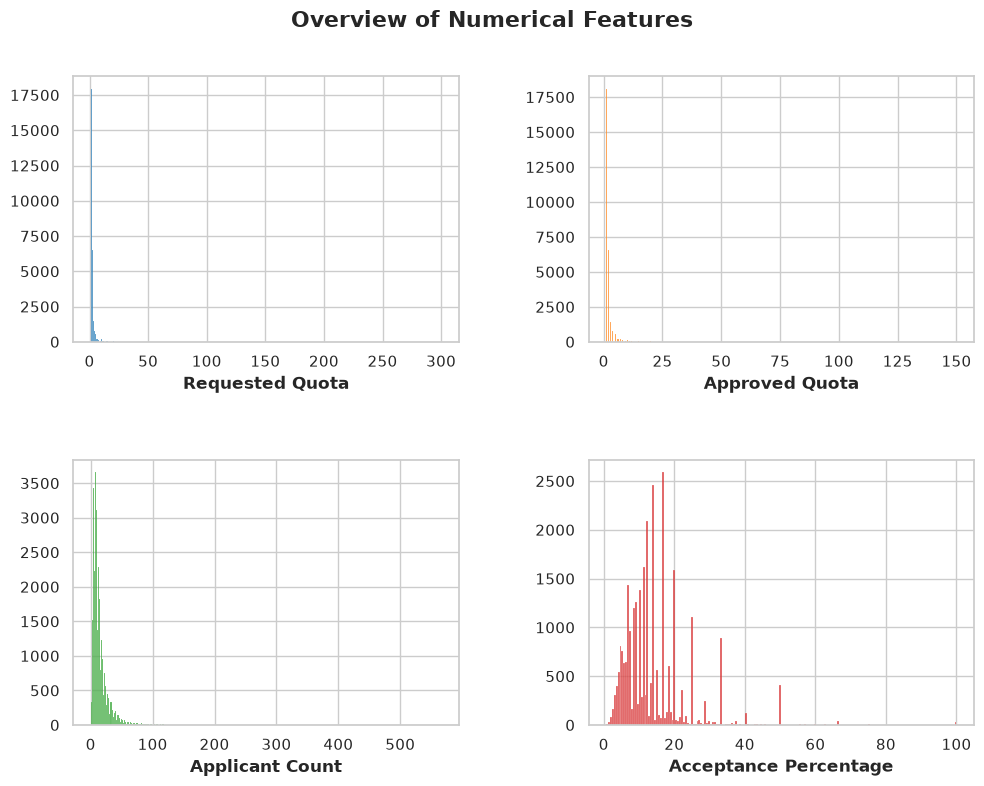

In [4]:
# Plot the numerical features
# Manually prepare the columns to visualize
plotted_cols = ["requested_quota", "approved_quota", "applicant_count", "acceptance_percentage"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.histplot(internship_postings, x=col, ax=ax, color=color)
    ax.set_xlabel(col.replace("_", " ").title(), fontweight="bold")
    ax.set_ylabel(None)

# Set the main title
fig.suptitle("Overview of Numerical Features", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

## 1.2 Categorical Features

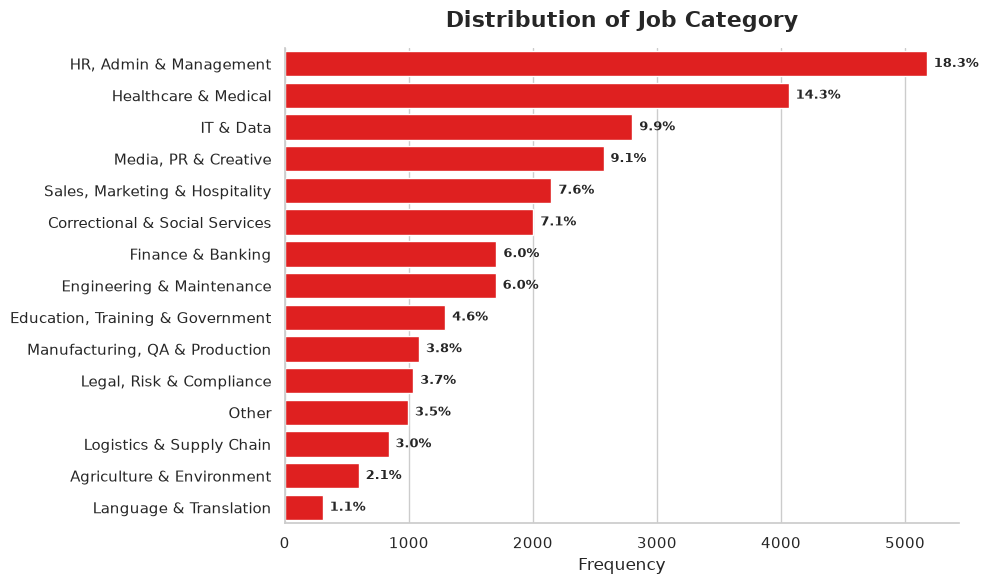

In [5]:
# Plot the job category distribution
# Set the target column
target_col = "job_category"
total_rows = len(internship_postings)

# Pre-calculate and sort frequencies for readability
category_counts = internship_postings[target_col].value_counts().reset_index()
category_counts.columns = [target_col, "count"]

# Set the canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Plot `province`
sns.barplot(
    data=category_counts, 
    y=target_col, 
    x="count", 
    color="red",
    ax=ax
)

# Add exact percentages to the end of the bars
for container in ax.containers:
    # Use bar.get_width() because the bars are now horizontal
    labels = [f"{(bar.get_width() / total_rows) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=5, fontweight="bold", fontsize=9)    # type: ignore

# Formatting
ax.set_title(
    f"Distribution of {target_col.replace("_", " ").title()}",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("")
ax.set_xlabel("Frequency")

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

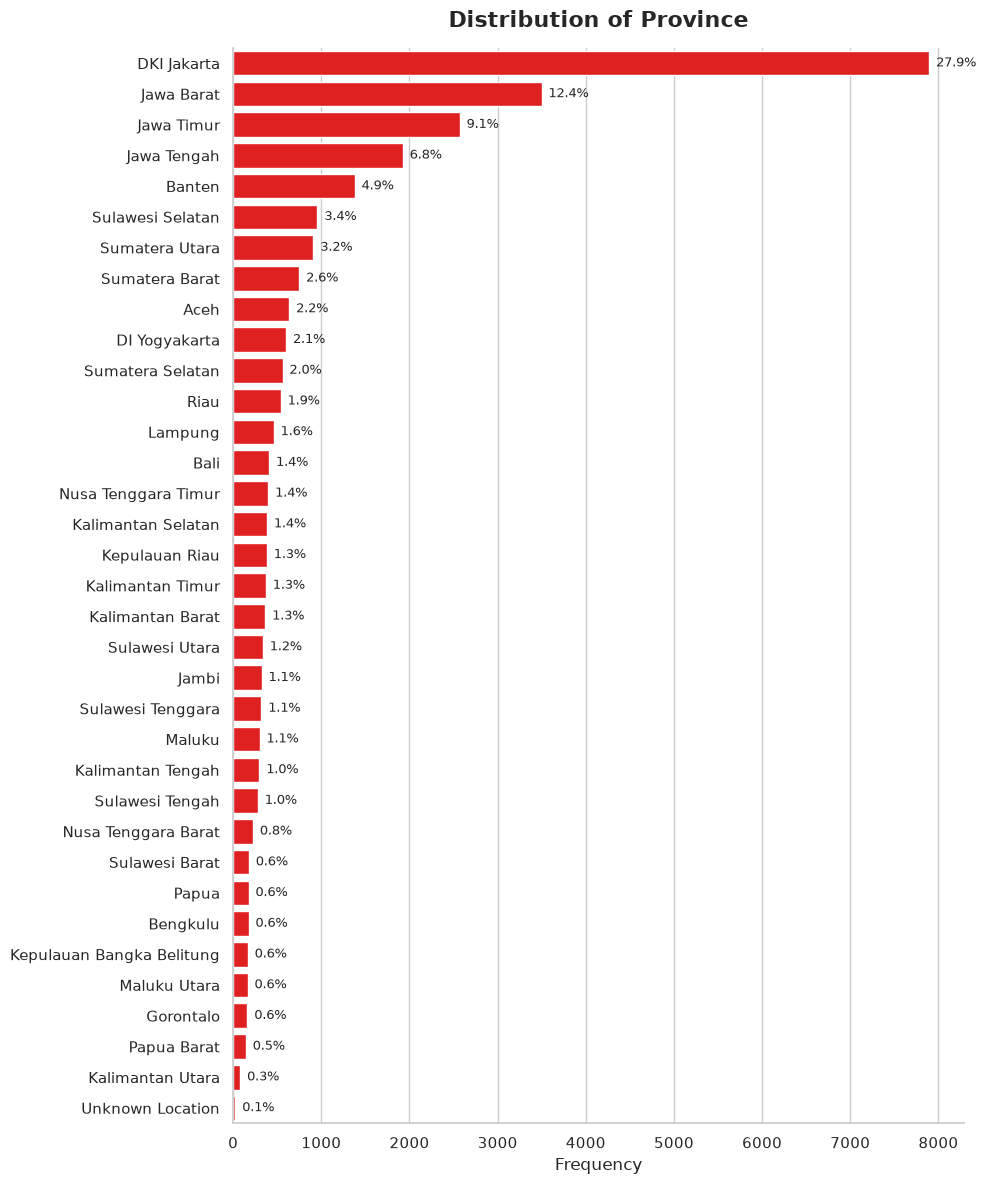

In [6]:
# Plot the province distribution
# Set the target column
target_col = "province"
total_rows = len(internship_postings)

# Pre-calculate and sort frequencies for readability
category_counts = internship_postings[target_col].value_counts().reset_index()
category_counts.columns = [target_col, "count"]

# Set the canvas
fig, ax = plt.subplots(figsize=(10, 12))

# Plot `province`
sns.barplot(
    data=category_counts, 
    y=target_col, 
    x="count", 
    color="red",
    ax=ax
)

# Add exact percentages to the end of the bars
for container in ax.containers:
    # Use bar.get_width() because the bars are now horizontal
    labels = [f"{(bar.get_width() / total_rows) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=5, fontsize=9)    # type: ignore

# Formatting
ax.set_title(
    f"Distribution of {target_col.replace("_", " ").title()}",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("")
ax.set_xlabel("Frequency")

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

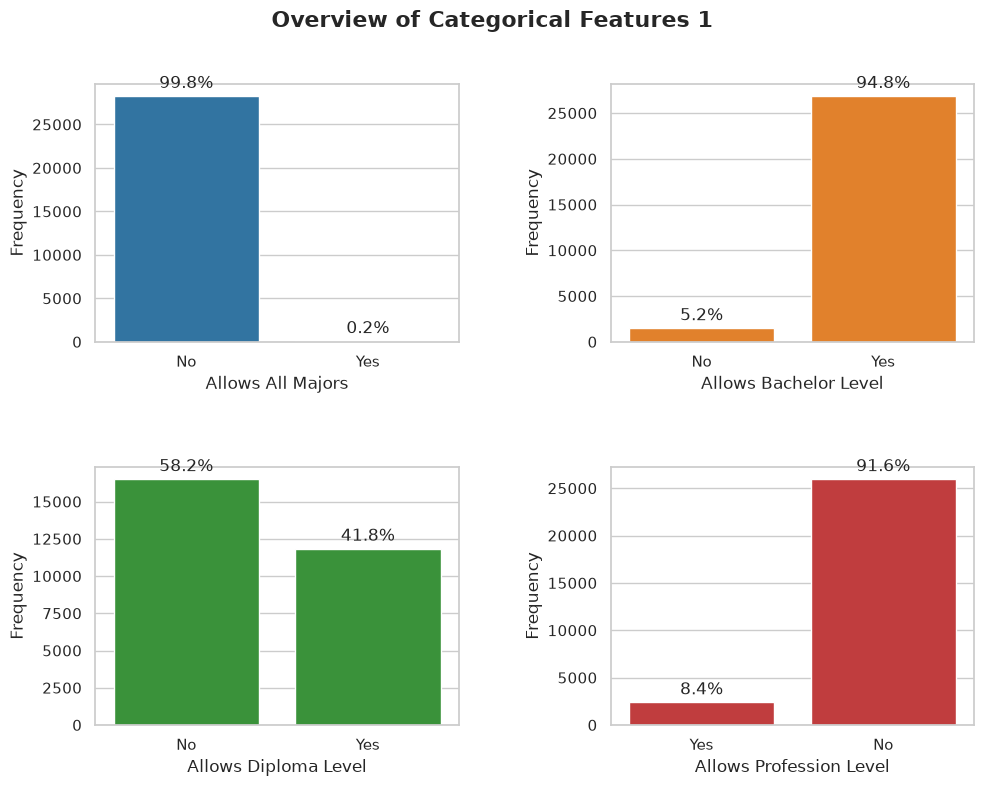

In [7]:
# Plot the remaining categorical features
# Manually prepare the columns to visualize
plotted_cols = ["allows_all_majors", "allows_bachelor_level", "allows_diploma_level", "allows_profession_level"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Get the total number of rows to calculate percentages
total_rows = len(internship_postings)

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.countplot(internship_postings, x=col, ax=ax, color=color)
    
    # Calculate and display exact percentages on top of bars
    for container in ax.containers:
        labels = [f"{(bar.get_height() / total_rows) * 100:.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=3)
        
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Frequency")

# Set the main title
fig.suptitle("Overview of Categorical Features 1", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

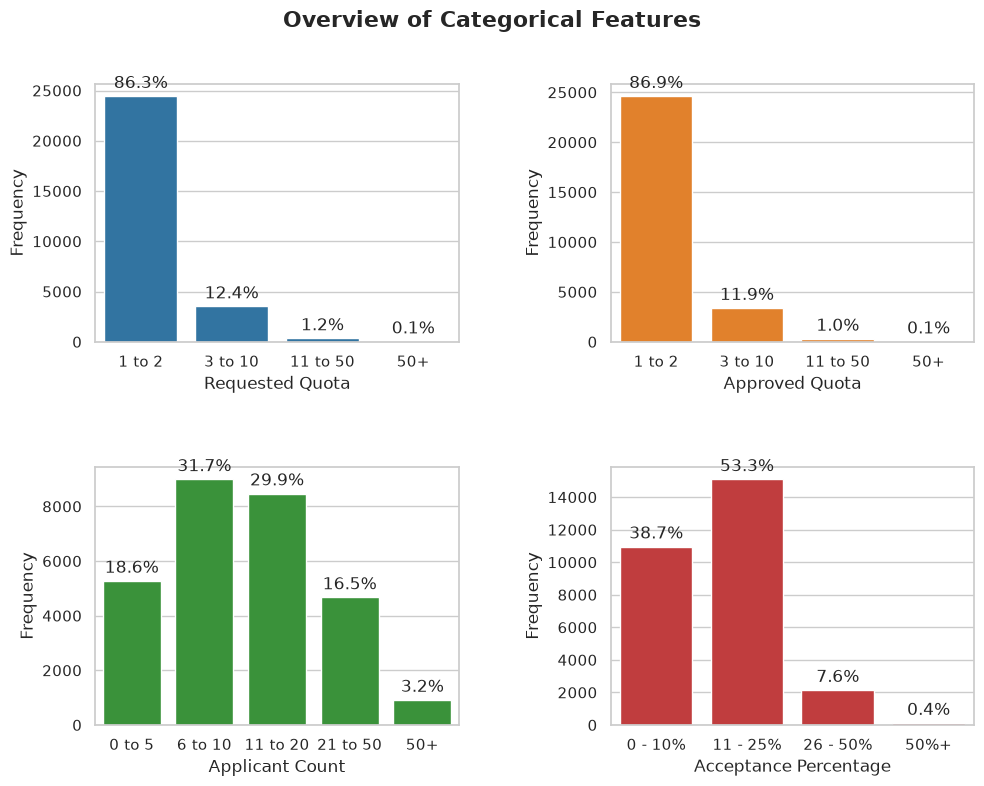

In [8]:
# Plot the categorical features
# Manually prepare the columns to visualize
plotted_cols = ["requested_quota_category", "approved_quota_category", "applicant_count_category", "acceptance_percentage_category"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Get the total number of rows to calculate percentages
total_rows = len(internship_postings)

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.countplot(internship_postings, x=col, ax=ax, color=color)
    
    # Calculate and display exact percentages on top of bars
    for container in ax.containers:
        labels = [f"{(bar.get_height() / total_rows) * 100:.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=3)
        
    ax.set_xlabel(col.removesuffix("_category").replace("_", " ").title())
    ax.set_ylabel("Frequency")

# Set the main title
fig.suptitle("Overview of Categorical Features", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

# 2. Bivariate Analysis
## 2.1 Categorical vs. Numerical (Performance)
### 2.1.1 Side-by-Side Boxplots
Mapping `applicant_count` and `acceptance_percentage` against `job_category` and `province`.

In [9]:
# Order categories by job count for intuitive visual hierarchy
job_order = internship_postings.job_category.value_counts().sort_values(ascending=False).index
province_order = internship_postings.province.value_counts().sort_values(ascending=False).head(10).index

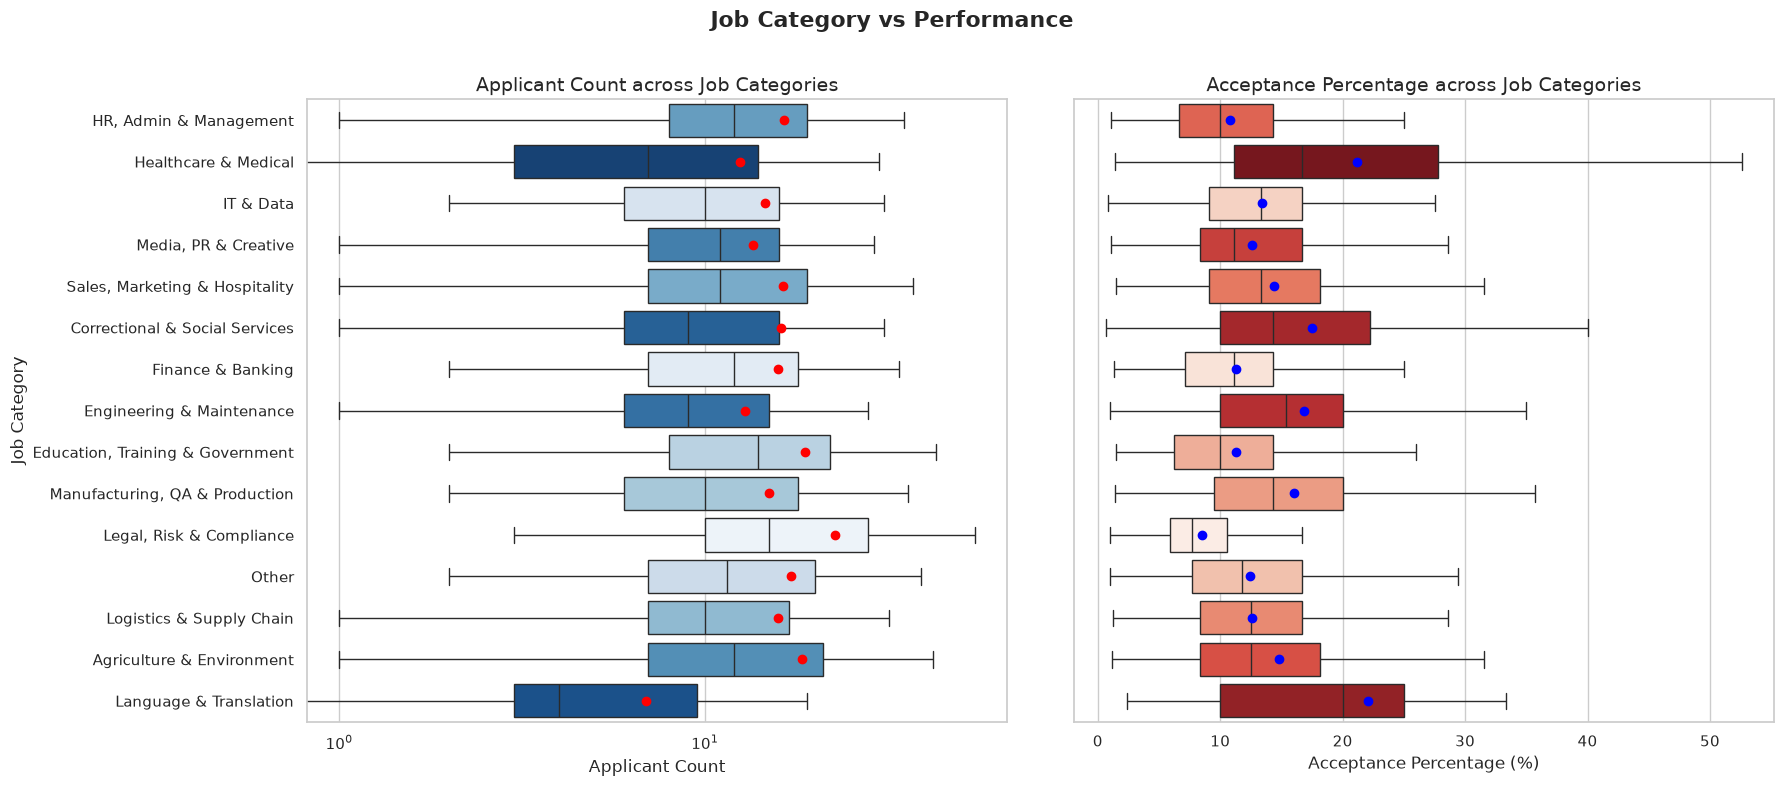

In [17]:
# Job Category vs Performance
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# Set the main title
fig.suptitle("Job Category vs Performance", fontsize=16, fontweight="bold")

sns.boxplot(
    data=internship_postings,
    y="job_category",
    x="applicant_count",
    hue="job_category",
    legend=False,
    order=job_order,
    ax=axes[0],
    palette="Blues_r",
    showmeans=True,
    showfliers=False,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[0].set_title("Applicant Count across Job Categories", fontsize=14)
axes[0].set_xlabel("Applicant Count")
axes[0].set_ylabel("Job Category")
axes[0].set_xscale("log")  # Due to the heavily right-skewed distribution

sns.boxplot(
    data=internship_postings,
    x="acceptance_percentage",
    y="job_category",
    hue="job_category",
    legend=False,
    order=job_order,
    ax=axes[1],
    palette="Reds_r",
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "blue",
    },
)
axes[1].set_title("Acceptance Percentage across Job Categories", fontsize=14)
axes[1].set_xlabel("Acceptance Percentage (%)")
axes[1].set_ylabel("")
axes[1].tick_params(left=False, labelleft=False)

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

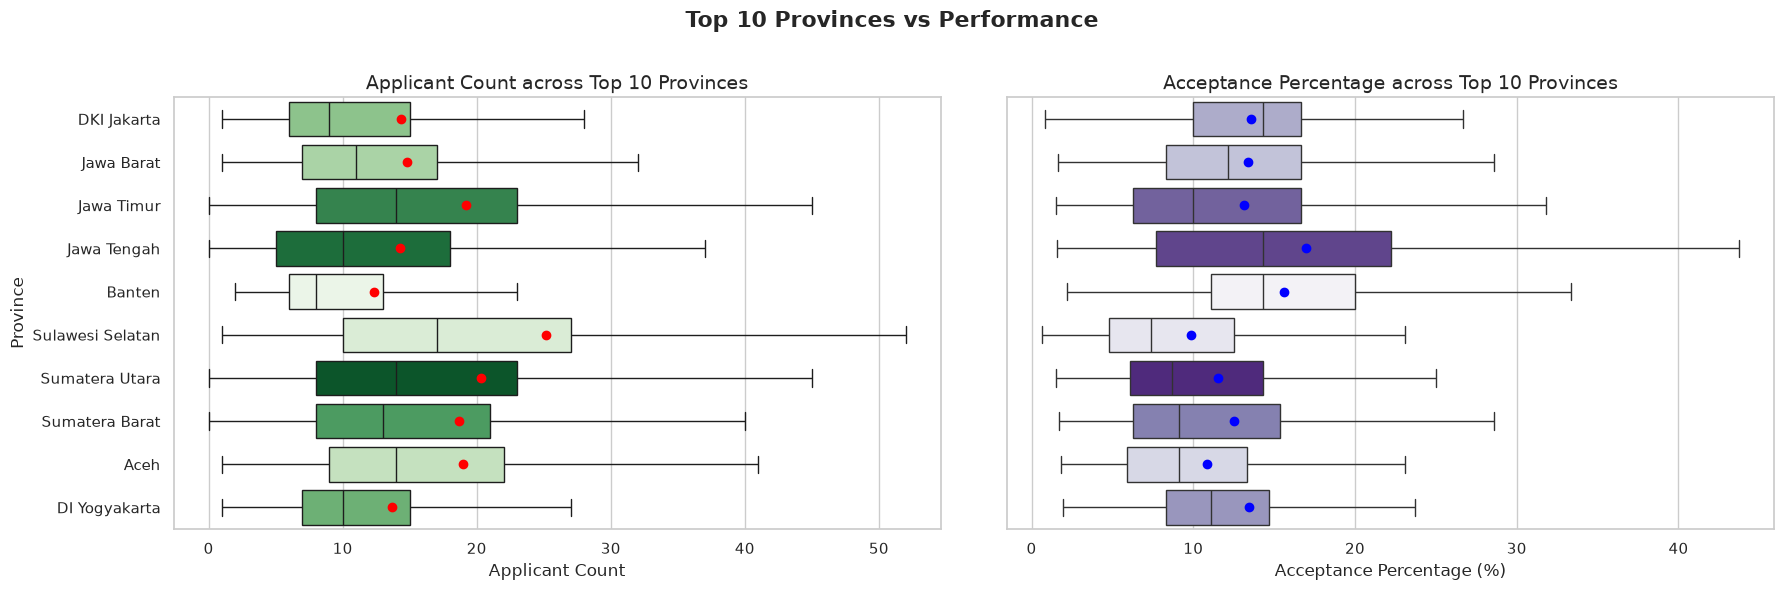

In [15]:
# Top 10 Provinces vs Performance
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Set the main title
fig.suptitle("Top 10 Provinces vs Performance", fontsize=16, fontweight="bold")

top_prov_df = internship_postings[
    internship_postings["province"].isin(province_order.to_list())
]

sns.boxplot(
    data=top_prov_df,
    y="province",
    x="applicant_count",
    hue="province",
    legend=False,
    order=province_order,
    ax=axes[0],
    palette="Greens_r",
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[0].set_title("Applicant Count across Top 10 Provinces", fontsize=14)
axes[0].set_xlabel("Applicant Count")
axes[0].set_ylabel("Province")

sns.boxplot(
    data=top_prov_df,
    y="province",
    x="acceptance_percentage",
    hue="province",
    legend=False,
    order=province_order,
    ax=axes[1],
    palette="Purples_r",
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "blue",
    },
)
axes[1].set_title("Acceptance Percentage across Top 10 Provinces", fontsize=14)
axes[1].set_xlabel("Acceptance Percentage (%)")
axes[1].set_ylabel("")
axes[1].tick_params(left=False, labelleft=False)

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

### 2.1.2 Kruskal-Wallis H-Test (Non-Parametric ANOVA)
Testing if the distribution of an outcome variable significantly differs across independent groups. This is ideal for right-skewed data because it evaluates the ranks rather than raw values.

This tests the null hypothesis, $H_0$, that the distribution of a given metric (e.g., `applicant_count` or `acceptance_percentage`) is identical across all categories of a grouping variable (e.g., `job_category` or `province`).

In [18]:
def run_kruskal(df, group_col, target_col):
    """Runs Kruskal-Wallis H-test for non-normal distributions."""
    valid_data = df[[group_col, target_col]].dropna()
    groups = [group[target_col].values for _, group in valid_data.groupby(group_col)]
    
    h_stat, p_val = stats.kruskal(*groups)
    
    print(f"Kruskal-Wallis for [{target_col}] across [{group_col}]:")
    print(f"  H-Statistic : {h_stat:.4f}")
    print(f"  p-value     : {p_val:.4e}")
    if p_val < 0.05:
        print("  Verdict     : Significant difference in distributions/mean ranks (Reject H0).\n")
    else:
        print("  Verdict     : No significant variation detected (Fail to reject H0).\n")

run_kruskal(internship_postings, "job_category", "applicant_count")
run_kruskal(internship_postings, "job_category", "acceptance_percentage")
run_kruskal(internship_postings, "province", "applicant_count")
run_kruskal(internship_postings, "province", "acceptance_percentage")

Kruskal-Wallis for [applicant_count] across [job_category]:
  H-Statistic : 2065.6596
  p-value     : 0.0000e+00
  Verdict     : Significant difference in distributions/mean ranks (Reject H0).

Kruskal-Wallis for [acceptance_percentage] across [job_category]:
  H-Statistic : 3556.5683
  p-value     : 0.0000e+00
  Verdict     : Significant difference in distributions/mean ranks (Reject H0).

Kruskal-Wallis for [applicant_count] across [province]:
  H-Statistic : 2217.2891
  p-value     : 0.0000e+00
  Verdict     : Significant difference in distributions/mean ranks (Reject H0).

Kruskal-Wallis for [acceptance_percentage] across [province]:
  H-Statistic : 2912.4684
  p-value     : 0.0000e+00
  Verdict     : Significant difference in distributions/mean ranks (Reject H0).



### 2.1.3 Dunn's Test (Non-Parametric Post-Hoc)
Replacing Tukey HSD. This identifies exactly which provinces and industries differ from each other.

In [ ]:
def get_differing_group_pairs(data: pd.DataFrame, val_col: str, group_col: str):
    # Run Dunn's test with Bonferroni correction for multiple comparisons
    dunn_p_values = sp.posthoc_dunn(
        data, 
        val_col=val_col, 
        group_col=group_col, 
        p_adjust="bonferroni"
    )
    
    group_name = group_col.replace("_", " ").title()

    # Unpivot the matrix into a list of all possible pairs
    stacked_p = dunn_p_values.stack().reset_index()
    stacked_p.columns = [f"{group_name} 1", f"{group_name} 2", "p_value"]

    # Filter for p < 0.05 AND keep only unique pairs 
    # (Group 1 < Group 2 ensures we don't get both A-B and B-A)
    significant_gaps = stacked_p[
        (stacked_p["p_value"] < 0.05) & 
        (stacked_p[f"{group_name} 1"] < stacked_p[f"{group_name} 2"])
    ]

    # Sort by the strongest statistical significance
    significant_gaps = significant_gaps.sort_values("p_value").reset_index(drop=True)
    print(f"Comparing {val_col} between {group_col}s using Dunn's test:")
    print(significant_gaps)

In [17]:
cat_cols = [
    "job_category", "province", "allows_all_majors", "allows_bachelor_level", "allows_diploma_level", "allows_profession_level",
    "requested_quota_category", "approved_quota_category", "applicant_count_category", "acceptance_percentage_category"
]

for col in cat_cols:
    grouped_values = internship_postings[col].value_counts(normalize=True).mul(100).round(1).to_dict()
    print("===================================================================")
    print(f"Univariate Analysis of Column {col} - Internship Postings (%)")
    print("-------------------------------------------------------------------")
    for value, count in grouped_values.items():
        print(f"{value}: {count}%")
    print("")

Univariate Analysis of Column job_category - Internship Postings (%)
-------------------------------------------------------------------
HR, Admin & Management: 18.3%
Healthcare & Medical: 14.3%
IT & Data: 9.9%
Media, PR & Creative: 9.1%
Sales, Marketing & Hospitality: 7.6%
Correctional & Social Services: 7.1%
Finance & Banking: 6.0%
Engineering & Maintenance: 6.0%
Education, Training & Government: 4.6%
Manufacturing, QA & Production: 3.8%
Legal, Risk & Compliance: 3.7%
Other: 3.5%
Logistics & Supply Chain: 3.0%
Agriculture & Environment: 2.1%
Language & Translation: 1.1%

Univariate Analysis of Column province - Internship Postings (%)
-------------------------------------------------------------------
DKI Jakarta: 27.9%
Jawa Barat: 12.4%
Jawa Timur: 9.1%
Jawa Tengah: 6.8%
Banten: 4.9%
Sulawesi Selatan: 3.4%
Sumatera Utara: 3.2%
Sumatera Barat: 2.6%
Aceh: 2.2%
DI Yogyakarta: 2.1%
Sumatera Selatan: 2.0%
Riau: 1.9%
Lampung: 1.6%
Bali: 1.4%
Nusa Tenggara Timur: 1.4%
Kalimantan Selatan: 1

Notes:
* All numerical data is highly right-skewed, so assumptions for normality are unmet. Thus, proceed with non-parametric tests (which rely on medians and ranks).
* Based on the visualization of the province distribution, it is evident that most internships are concentrated in a few provinces where 27.9% in DKI Jakarta, 12.4% in West Java, 9.1% in East Java, and 6.5% in Central Java. The remaining provinces have a significantly lower representation, with less than 5% each. This indicates a strong regional preference for internships in these areas, which could be due to the presence of major cities, economic hubs, or educational institutions that attract more internship opportunities.
* Based on the Kruskal-Wallis H-Test, the extreme p-values confirm that the disparities in the dataset are structural, not random noise. The industry you choose and the province you are in absolutely dictate the volume of competition.
* 

<!-- Findings:
* All the numerical features, `weekly_working_day`, `requested_quota`, `approved_quota`, `applicant_count`, and `acceptance_percentage`, are highly right skewed.
* Consider transforming Column `weekly_working_day` to a categorical feature, as it has only 2 unique values.
* Bin the rest of the numerical features to make logical sense to stakeholders, manually define the edges. Since the tail is long, increase the bin sizes exponentially to catch the massive outliers in a single "Extreme" bucket. -->